In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm
from scipy.stats import poisson, nbinom


In [34]:
df = pd.read_csv("football_data_adjcols.csv")

In [35]:
X_home = df.drop(columns = ["Unnamed: 0","date","home_shots","away_shots","odds_h","odds_a","odds_d"])
X_away = df.drop(columns = ["Unnamed: 0","date","home_shots","away_shots","odds_h","odds_a","odds_d"])

y_home = df["home_shots"]
y_away = df["away_shots"]

In [36]:
X_home_active = X_home[["home_adj_shots", "away_adj_shots_conc", "prob_h"]]
X_away_active = X_away[["home_adj_shots_conc", "away_adj_shots"]]

                     home_adj_shots  away_adj_shots_conc    prob_h  home_shots
home_adj_shots             1.000000             0.054522  0.442080    0.295543
away_adj_shots_conc        0.054522             1.000000  0.372692    0.312499
prob_h                     0.442080             0.372692  1.000000    0.462590
home_shots                 0.295543             0.312499  0.462590    1.000000
                     home_adj_shots  away_adj_shots_conc    prob_h
home_adj_shots             1.000000             0.054522  0.442080
away_adj_shots_conc        0.054522             1.000000  0.372692
prob_h                     0.442080             0.372692  1.000000


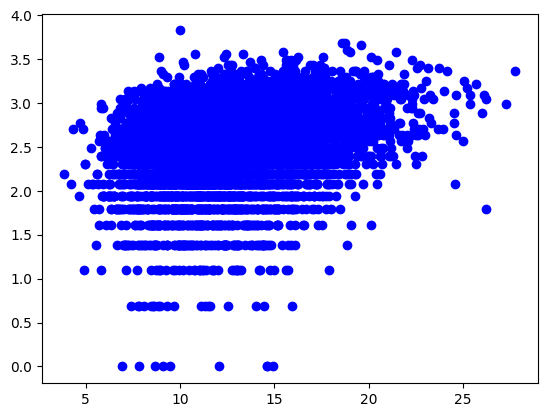

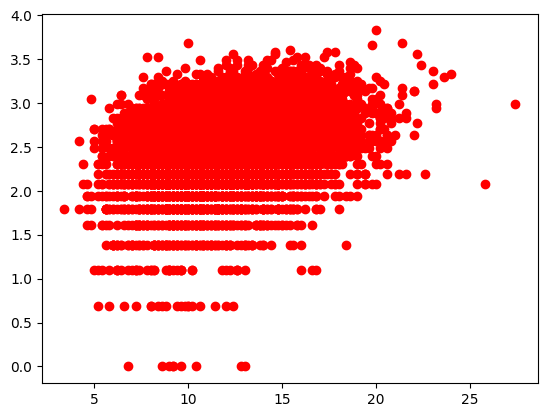

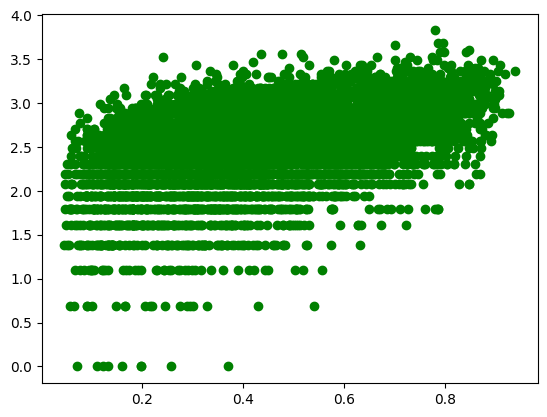

In [37]:
y_for_checks = np.log(y_home)

print(pd.concat([X_home_active, y_for_checks], axis = 1).corr())
print(X_home_active.corr())
plt.scatter(X_home_active["home_adj_shots"], y_for_checks, color = "blue", label = "Home Shots")
plt.show()
plt.scatter(X_home_active["away_adj_shots_conc"], y_for_checks, color = "red", label = "Away Shots Conceded")
plt.show()
plt.scatter(X_home_active["prob_h"], y_for_checks, color = "green", label = "Home Odds")
plt.show()

In [38]:
split_idx = int(len(y_home) * 0.8)

X_home_train, X_home_test = X_home_active[:split_idx], X_home_active[split_idx:]
y_home_train, y_home_test = y_home[:split_idx], y_home[split_idx:]

In [39]:
X_home_train_const = sm.add_constant(X_home_train)

poisson_model = sm.GLM(y_home_train, X_home_train_const, family=sm.families.Poisson())
poisson_result = poisson_model.fit()

print(poisson_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             home_shots   No. Observations:                 5806
Model:                            GLM   Df Residuals:                     5802
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -17193.
Date:                Wed, 22 Apr 2026   Deviance:                       9051.5
Time:                        23:30:19   Pearson chi2:                 9.07e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.4383
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.7313    

In [47]:
neg_bin_model = sm.NegativeBinomial(y_home_train, X_home_train_const)
neg_bin_result = neg_bin_model.fit()

print(neg_bin_result.summary())

Optimization terminated successfully.
         Current function value: 2.906941
         Iterations: 14
         Function evaluations: 18
         Gradient evaluations: 18
                     NegativeBinomial Regression Results                      
Dep. Variable:             home_shots   No. Observations:                 5806
Model:               NegativeBinomial   Df Residuals:                     5802
Method:                           MLE   Df Model:                            3
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                 0.05148
Time:                        23:40:48   Log-Likelihood:                -16878.
converged:                       True   LL-Null:                       -17794.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               

In [50]:
X_home_test_const = sm.add_constant(X_home_test, has_constant='add')

# --- Point predictions ---
poisson_preds = poisson_result.predict(X_home_test_const)
nb_preds      = neg_bin_result.predict(X_home_test_const)

# --- MAE & RMSE ---
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

print("=== Point Prediction ===")
print(f"Poisson  MAE: {mae(y_home_test, poisson_preds):.4f}  RMSE: {rmse(y_home_test, poisson_preds):.4f}")
print(f"NegBin   MAE: {mae(y_home_test, nb_preds):.4f}  RMSE: {rmse(y_home_test, nb_preds):.4f}")

=== Point Prediction ===
Poisson  MAE: 3.6756  RMSE: 4.6715
NegBin   MAE: 3.6762  RMSE: 4.6716


In [51]:
# --- Log-likelihood ---
alpha = neg_bin_result.params['alpha']

def poisson_loglik(y_true, mu):
    return np.sum(poisson.logpmf(y_true.astype(int), mu))

def nb_loglik(y_true, mu, alpha):
    # Convert mu/alpha to scipy's n, p parametrisation
    n = 1.0 / alpha
    p = n / (n + mu)
    return np.sum(nbinom.logpmf(y_true.astype(int), n, p))

poisson_ll = poisson_loglik(y_home_test, poisson_preds)
neg_bin_ll      = nb_loglik(y_home_test, nb_preds, alpha)

print("\n=== Log-Likelihood (higher is better) ===")
print(f"Poisson  LL: {poisson_ll:.2f}")
print(f"NegBin   LL: {neg_bin_ll:.2f}")
print(f"Difference:  {neg_bin_ll - poisson_ll:.2f} (in favour of NegBin)")


=== Log-Likelihood (higher is better) ===
Poisson  LL: -4343.88
NegBin   LL: -4255.36
Difference:  88.52 (in favour of NegBin)


In [52]:
def predict_negbin_distribution(model, X_row, max_shots=50, plot=True):
    """
    Given a trained NegativeBinomial model and a single row of X,
    returns the full PMF over shot counts.
    
    Parameters
    ----------
    model     : fitted sm.NegativeBinomial result object
    X_row     : pd.Series or single-row pd.DataFrame (without constant)
    max_shots : upper bound of shot range to evaluate
    plot      : whether to plot the distribution
    
    Returns
    -------
    pmf : np.array of probabilities for counts 0..max_shots
    mu  : predicted mean
    """
    import statsmodels.api as sm

    # Add constant and ensure correct shape
    X_const = sm.add_constant(X_row, has_constant='add')

    # Predicted mean
    mu    = model.predict(X_const).values[0]
    alpha = model.params['alpha']

    # Convert to scipy NegBin parametrisation
    n = 1.0 / alpha
    p = n / (n + mu)

    # PMF over 0..max_shots
    counts = np.arange(0, max_shots + 1)
    pmf    = nbinom.pmf(counts, n, p)

    if plot:
        plt.figure(figsize=(10, 4))
        plt.bar(counts, pmf, color='steelblue', alpha=0.8)
        plt.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mu:.1f}')
        plt.xlabel('Home shots')
        plt.ylabel('Probability')
        plt.title('NegBin Predicted Distribution')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return pmf, mu

home_team                   Como
away_team                  Inter
league                   serie_a
season                      2425
prob_h                  0.193459
prob_d                  0.219254
prob_a                  0.587287
home_adj_shots         16.397056
home_adj_shots_conc         11.2
away_adj_shots         15.528509
away_adj_shots_conc         13.2
Name: 7248, dtype: object
18.0


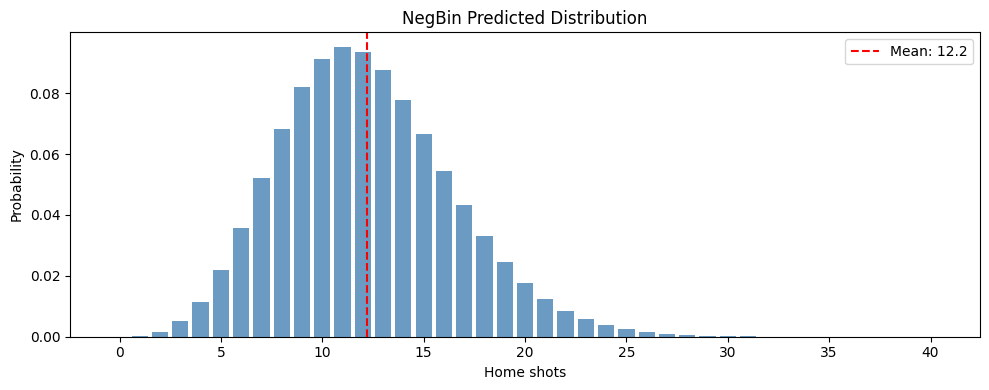

In [62]:
# Using row 0 of X_test as an example
id = -10
row = X_home_test.iloc[[id]]
print(X_home.iloc[id])
print(y_home.iloc[id])
pmf, mu = predict_negbin_distribution(neg_bin_result, row, max_shots = 40)

In [63]:
pmf

array([4.90333225e-05, 4.00947461e-04, 1.70542690e-03, 5.02357845e-03,
       1.15126256e-02, 2.18666581e-02, 3.58130679e-02, 5.19632483e-02,
       6.81150381e-02, 8.18636209e-02, 9.12495810e-02, 9.52021819e-02,
       9.36664444e-02, 8.74438802e-02, 7.78644781e-02, 6.64249196e-02,
       5.44941735e-02, 4.31342024e-02, 3.30362169e-02, 2.45442258e-02,
       1.77282646e-02, 1.24738769e-02, 8.56494024e-03, 5.74812046e-03,
       3.77597666e-03, 2.43107884e-03, 1.53584711e-03, 9.53111655e-04,
       5.81586265e-04, 3.49262036e-04, 2.06593331e-04, 1.20459636e-04,
       6.92842548e-05, 3.93350804e-05, 2.20567892e-05, 1.22226975e-05,
       6.69704658e-06, 3.62998445e-06, 1.94729248e-06, 1.03430745e-06,
       5.44171263e-07])